# Vietnam Statistical Arbitrage: Clean Final Pipeline
## PCA Factor Model + OU Mean Reversion + Long-Only + A1B2 Comparison

**Overview:** Statistical arbitrage strategy for Vietnam stocks combining PCA factor extraction, OU mean-reversion fitting, and long-only signal logic with position-based capital allocation.

**Pipeline:**
1. Load and align price/volume data
2.Select liquid universe (top 300 stocks)
3. Compute returns and align all series
4. Rolling PCA (252-day window, 5 factors)
5. Residual construction via OLS regression
6. OU model fitting to residuals
7. S-score computation
8. Signal generation (A1 dynamic + A1 fixed modes)
9. Backtest 1: Vietnam Long-Only (position-based, 30% deploy, T+2 settlement)
10. Backtest 2: A1B2 Framework (dynamic cutoff + bucket allocation, 30/40/50% fractions)
11. Results comparison and final diagnostics

**Currency:** All monetary values in thousands of VND (K VND). Initial capital = 100,000 K VND = 100M VND.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 2.3.3 | NumPy: 2.4.3


## Step 1: Load Data

In [14]:
# Load data files
prices_df = pd.read_csv('vietnam_stock_price_full.csv', index_col=0, parse_dates=True)
volume_df = pd.read_csv('vietnam_stock_volume_full.csv', index_col=0, parse_dates=True)
fu_df = pd.read_csv('FU_VN30_full.csv', index_col=0, parse_dates=True)

print(f'✓ Data loaded:')
print(f'  Prices: {prices_df.shape}')
print(f'  Volumes: {volume_df.shape}')
print(f'  FU_VN30: {fu_df.shape}')

✓ Data loaded:
  Prices: (2872, 702)
  Volumes: (2872, 702)
  FU_VN30: (2141, 5)


## Step 2-3: Universe Selection and Returns Computation

In [15]:
def top_liquidity_stocks(price_df, volume_df, top_n=300, average_window=60):
    price_win = price_df.tail(average_window)
    volume_win = volume_df.tail(average_window)
    liquidity = (price_win * volume_win).mean()
    top_stocks = liquidity.nlargest(min(top_n, len(liquidity))).index
    return price_df[top_stocks], volume_df[top_stocks].astype(float)

def fill_na_with_neighbors(df, min_neighbors=1):
    """Fill missing values with average of 2 before and 2 after neighbors."""
    s1, s2 = df.shift(1), df.shift(2)
    s_1, s_2 = df.shift(-1), df.shift(-2)
    neighbor_sum = s1.fillna(0) + s2.fillna(0) + s_1.fillna(0) + s_2.fillna(0)
    neighbor_count = (s1.notna().astype(int) + s2.notna().astype(int) + 
                     s_1.notna().astype(int) + s_2.notna().astype(int))
    neighbor_mean = neighbor_sum / neighbor_count.where(neighbor_count > 0)
    return df.where(df.notna(), neighbor_mean.where(neighbor_count >= min_neighbors))

def select_universe(prices_df, volume_df, date, top_n=300, lookback_window=3500):
    """Select liquid stocks for given date with data quality checks."""
    list_valid = prices_df.loc[date].notna()
    price = prices_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_valid]
    volume = volume_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_valid]
    common = price.columns.intersection(volume.columns)
    price, volume = price[common].ffill(limit=2).dropna(axis=1, how='any'), volume[common]
    volume = fill_na_with_neighbors(volume).dropna(axis=1, how='any')
    price = price[price.columns.intersection(volume.columns)]
    return top_liquidity_stocks(price, volume, top_n=top_n, average_window=lookback_window)

# Select universe and compute returns
reference_date = prices_df.index[-1]
prices_universe, volume_universe = select_universe(prices_df, volume_df, reference_date, top_n=300, lookback_window=3500)
stock_returns = prices_universe.pct_change()
stock_returns_for_pca = stock_returns.copy()

# Extract VN30 returns
fu_col = [col for col in fu_df.columns if 'price' in col.lower() or 'close' in col.lower() or col == 'Adj Close']
fu_col = fu_col[0] if fu_col else fu_df.columns[0]
vn30_returns = fu_df[fu_col].dropna().pct_change().dropna()

# Align dates
common_dates = stock_returns.index.intersection(vn30_returns.index)
stock_returns = stock_returns.reindex(common_dates)
vn30_returns = vn30_returns.reindex(common_dates)

print(f'✓ Universe selected: {stock_returns.shape[1]} stocks, {stock_returns.shape[0]} trading days')
print(f'  Date range: {stock_returns.index[0].date()} to {stock_returns.index[-1].date()}')

✓ Universe selected: 300 stocks, 2097 trading days
  Date range: 2017-08-11 to 2025-12-31


## Step 4: Rolling PCA Factor Extraction

In [16]:
def standardize_returns(returns_df):
    """Standardize returns: (R - mean) / std per stock."""
    mean_i = returns_df.mean(axis=0)
    std_i = returns_df.std(axis=0, ddof=1).replace(0, np.nan)
    return ((returns_df - mean_i) / std_i).dropna(axis=1)

def compute_empirical_correlation(standardized_returns):
    """Compute correlation matrix from standardized returns."""
    M = standardized_returns.shape[0]
    return (standardized_returns.values.T @ standardized_returns.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix):
    """Eigendecomposition with eigenvalues sorted descending."""
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

def window_pca_engine(returns_df, n_factors=5):
    """Perform PCA on returns (single window, fixed number of factors)."""
    Z = standardize_returns(returns_df)
    C = compute_empirical_correlation(Z)
    eigvals, eigvecs = eigen_decomposition_sorted(C)
    k = min(n_factors, returns_df.shape[1] - 1)
    V = eigvecs[:, :k]
    std_stocks = returns_df.std(ddof=1).replace(0, np.nan)
    Q = V / std_stocks.values.reshape(-1, 1)
    return {'Q': Q, 'V': V, 'k': k, 'stocks': returns_df.columns, 'eigenvalues': eigvals[:k]}

# Rolling PCA computation
print(f'Computing rolling PCA (252-day window, 5 factors)...')
pca_results_pipeline = {}
pca_dates_pipeline = []
window_size, min_stocks = 252, 20

for t in range(window_size, len(stock_returns_for_pca)):
    date = stock_returns_for_pca.index[t]
    ret_window = stock_returns_for_pca.iloc[t-window_size:t].dropna(axis=1, how='any')
    if ret_window.shape[1] >= min_stocks:
        try:
            pca_dict = window_pca_engine(ret_window, n_factors=5)
            pca_results_pipeline[date] = pca_dict
            pca_dates_pipeline.append(date)
            if len(pca_dates_pipeline) % 100 == 0:
                print(f'  {len(pca_dates_pipeline)} PCA windows computed')
        except:
            continue

print(f'✓ PCA extraction complete: {len(pca_dates_pipeline)} dates')

Computing rolling PCA (252-day window, 5 factors)...
  100 PCA windows computed
  200 PCA windows computed
  300 PCA windows computed
  400 PCA windows computed
  500 PCA windows computed
  600 PCA windows computed
  700 PCA windows computed
  800 PCA windows computed
  900 PCA windows computed
  1000 PCA windows computed
  1100 PCA windows computed
  1200 PCA windows computed
  1300 PCA windows computed
  1400 PCA windows computed
  1500 PCA windows computed
  1600 PCA windows computed
  1700 PCA windows computed
  1800 PCA windows computed
  1900 PCA windows computed
  2000 PCA windows computed
✓ PCA extraction complete: 2095 dates


## Step 5: Residual Construction

In [17]:
def compute_pca_residuals(returns_df, pca_dict, window=60):
    """Compute PCA residuals via OLS regression on factor returns."""
    returns_win = returns_df.iloc[-window:]
    Q = pca_dict['Q']
    stocks = pca_dict['stocks']
    R = returns_win[stocks].values
    F = R @ Q
    X = np.column_stack([np.ones(window), F])
    XtX_inv = np.linalg.pinv(X.T @ X)
    B = XtX_inv @ (X.T @ R)
    residuals = R - X @ B
    return pd.DataFrame(residuals, index=returns_win.index, columns=stocks)

# Compute residuals
print(f'Computing residuals from PCA results...')
residuals_list, dates_with_residuals = [], []
residual_window, min_obs_residual, min_stocks_residual = 60, 40, 10

for date in sorted(pca_dates_pipeline):
    if date not in stock_returns_for_pca.index:
        continue
    t = stock_returns_for_pca.index.get_loc(date)
    if t < residual_window:
        continue
    pca_dict = pca_results_pipeline[date]
    pca_stocks = list(pca_dict['stocks'])
    ret_window = stock_returns_for_pca.iloc[t-residual_window:t]
    common_stocks = [s for s in pca_stocks if s in ret_window.columns]
    if len(common_stocks) >= min_stocks_residual:
        ret_filtered = ret_window[common_stocks].dropna(axis=1, how='any').dropna(axis=0, how='any')
        if ret_filtered.shape[0] >= min_obs_residual:
            try:
                pca_filtered = {k: pca_dict[k] for k in ['Q', 'V', 'k', 'eigenvalues']}
                pca_filtered['stocks'] = ret_filtered.columns
                residuals_window = compute_pca_residuals(ret_filtered, pca_filtered, window=residual_window)
                residuals_list.append(residuals_window)
                dates_with_residuals.append(date)
            except:
                continue

if residuals_list:
    residuals_pipeline = pd.concat(residuals_list, axis=0).sort_index()
    residuals_pipeline = residuals_pipeline[~residuals_pipeline.index.duplicated(keep='first')]
    print(f'✓ Residuals computed: {residuals_pipeline.shape[0]} dates, {residuals_pipeline.shape[1]} stocks')
else:
    residuals_pipeline = pd.DataFrame()
    print('⚠ No residuals computed')

Computing residuals from PCA results...
✓ Residuals computed: 2154 dates, 300 stocks


## Step 6: OU/AR(1) Mean Reversion Fitting

In [18]:
def fit_ou_model(residuals, window=60, limit=False, kappa_min=8.4, min_obs=40, return_details=True):
    """Fit Ornstein-Uhlenbeck model to residuals."""
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()
    
    for col in residuals.columns:
        series = residuals[col]
        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue
            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue
            x_prev, x_next = Xcum[:-1], Xcum[1:]
            A = np.column_stack([np.ones(len(x_prev)), x_prev])
            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except:
                continue
            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)
            if not np.isfinite(b) or var_xi <= 1e-12 or b <= 0 or b >= 0.9672:
                continue
            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))
            if not (np.isfinite(kappa_val) and np.isfinite(mu_val) and np.isfinite(sigma_eq_val)):
                continue
            if sigma_eq_val <= 1e-12 or (limit and kappa_val < kappa_min):
                continue
            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val
    
    ou_daily_df = pd.concat({'kappa': kappa, 'mu': mu, 'sigma_eq': sigma_eq}, axis=1)
    ou_daily_df = ou_daily_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
    ou_daily_df.columns.names = ['Stock', 'Stat']
    if return_details:
        return ou_daily_df, kappa, mu, sigma_eq
    return ou_daily_df

# Fit OU model
print('Fitting OU model to residuals...')
ou_daily_df, kappa_df, mu_df, sigma_eq_df = fit_ou_model(residuals_pipeline, window=60, limit=False, return_details=True)
print(f'✓ OU parameters fitted: {ou_daily_df.shape[0]} dates, {ou_daily_df.columns.get_level_values("Stock").nunique()} stocks')

Fitting OU model to residuals...
✓ OU parameters fitted: 2154 dates, 300 stocks


## Step 7: S-Score Computation

In [19]:
def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    """Compute standardized S-score: (X_t - mu) / sigma_eq."""
    sscore_df = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    for col in residuals.columns:
        eps = residuals[col]
        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue
            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]
            if pd.notna(mu_t) and pd.notna(sigma_t) and sigma_t > 1e-12:
                sscore_df.iloc[t, sscore_df.columns.get_loc(col)] = (x_t - mu_t) / sigma_t
    return sscore_df

# Compute s-scores
print('Computing s-scores...')
sscore_df = compute_s_score(residuals_pipeline, mu_df, sigma_eq_df, window=60)
print(f'✓ S-scores computed: {sscore_df.shape[0]} dates, {sscore_df.shape[1]} stocks')

Computing s-scores...
✓ S-scores computed: 2154 dates, 300 stocks


## Step 8: Signal Generation Helpers

In [20]:
def compute_dynamic_entry_cutoff(s_df, entry_pct=5, ma_window=60, min_valid_stocks=5):
    """A1 Dynamic: Daily cross-sectional quantile + rolling MA smoothing."""
    def row_quantile(row):
        valid = row.dropna()
        return valid.quantile(entry_pct / 100.0) if len(valid) >= min_valid_stocks else np.nan
    raw_cutoff = s_df.apply(row_quantile, axis=1)
    min_periods = max(10, ma_window // 6)
    entry_cutoff = raw_cutoff.rolling(window=ma_window, min_periods=min_periods).mean()
    return raw_cutoff, entry_cutoff

def compute_fixed_entry_cutoff(s_df, fixed_cutoff=-1.5):
    """A1 Fixed: Constant threshold across all dates."""
    return pd.Series(fixed_cutoff, index=s_df.index, dtype=float), pd.Series(fixed_cutoff, index=s_df.index, dtype=float)

def generate_long_only_signals(s_df, entry_cutoff_series, close_cutoff=-0.5):
    """Generate long-only signals (1=long, 0=no) and actions (1=open, -1=close, 0=hold)."""
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    actions = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)
    
    for t in range(1, len(s_df)):
        date, prev_date = s_df.index[t], s_df.index[t - 1]
        s_prev = s_df.loc[prev_date]
        entry_cutoff_prev = entry_cutoff_series.loc[prev_date]
        prev_state = current.copy()
        
        for stock in s_df.columns:
            val = s_prev[stock]
            if pd.isna(val):
                current[stock] = 0
                continue
            if current[stock] == 0:
                if pd.notna(entry_cutoff_prev) and val < entry_cutoff_prev:
                    current[stock] = 1
            else:
                if val > close_cutoff:
                    current[stock] = 0
        
        action_today = pd.Series(0, index=s_df.columns, dtype=int)
        for stock in s_df.columns:
            if prev_state[stock] == 0 and current[stock] == 1:
                action_today[stock] = 1
            elif prev_state[stock] == 1 and current[stock] == 0:
                action_today[stock] = -1
        
        signals.loc[date] = current.values
        actions.loc[date] = action_today.values
    
    return signals, actions

print('✓ Signal generation helpers loaded')

✓ Signal generation helpers loaded


## Step 9: Vietnam Long-Only Backtest (Position-Based Capital Allocation)

In [21]:
def backtest_vietnam_longonly(signals_df, prices_df, initial_cash=100000, invest_frac=0.30, settlement_days=2):
    """Vietnam-feasible long-only backtest with position-based accounting and 30% daily deployment."""
    common_idx = signals_df.index.intersection(prices_df.index)
    signals = signals_df.loc[common_idx]
    prices = prices_df.loc[common_idx]
    
    position_book = {}
    cash = initial_cash
    equity_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    cash_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    holdings_per_day = []
    
    for t, date in enumerate(common_idx):
        price_dict = prices.loc[date].to_dict()
        
        # Mark positions to market and process exits
        total_pos_value = 0
        for stock in list(position_book.keys()):
            pos = position_book[stock]
            if price_dict.get(stock, np.nan) > 0:
                total_pos_value += pos['shares'] * price_dict[stock]
        
        # Process exits (stocks with signal=0 and older than T+2)
        for stock in list(position_book.keys()):
            if signals.loc[date, stock] == 0:
                entry_date = pd.Timestamp(position_book[stock]['entry_date'])
                bday_diff = pd.bdate_range(start=entry_date, end=date).size - 1
                if bday_diff >= settlement_days and price_dict.get(stock, np.nan) > 0:
                    cash += position_book[stock]['shares'] * price_dict[stock]
                    del position_book[stock]
        
        # Identify new entries and allocate capital
        current_holdings = set(position_book.keys())
        new_entries = [s for s in signals.columns if signals.loc[date, s] == 1 and s not in current_holdings]
        
        investable = invest_frac * cash
        if new_entries and investable > 0:
            per_stock = investable / len(new_entries)
            for stock in new_entries:
                price = price_dict.get(stock, np.nan)
                if price > 0 and per_stock > 0:
                    shares = per_stock / price
                    position_book[stock] = {
                        'entry_date': date,
                        'shares': shares,
                        'cost_basis': per_stock,
                        'entry_price': price
                    }
                    cash -= per_stock
        
        # Update equity
        total_pos_value = sum(pos['shares'] * price_dict.get(stock, 0) for stock, pos in position_book.items())
        total_equity = max(0, cash + total_pos_value)
        equity_curve.iloc[t] = total_equity
        cash_curve.iloc[t] = max(0, cash)
        holdings_per_day.append(len(position_book))
    
    daily_ret = equity_curve.pct_change().dropna()
    total_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100 if equity_curve.iloc[0] > 0 else 0
    ann_ret = daily_ret.mean() * 252 if len(daily_ret) > 0 else 0
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else 0
    sharpe = ann_ret / ann_vol if ann_vol > 1e-10 else 0
    cum_max = equity_curve.cummax()
    max_dd = ((cum_max - equity_curve) / cum_max).max() if len(equity_curve) > 0 else 0
    
    return {
        'equity_curve': equity_curve,
        'cash_curve': cash_curve,
        'holdings_per_day': holdings_per_day,
        'metrics': {
            'final_equity': equity_curve.iloc[-1],
            'final_cash': cash_curve.iloc[-1],
            'total_return_pct': total_ret,
            'annualized_return': ann_ret * 100 if np.isfinite(ann_ret) else 0,
            'annualized_volatility': ann_vol * 100 if np.isfinite(ann_vol) else 0,
            'sharpe_ratio': sharpe if np.isfinite(sharpe) else 0,
            'max_drawdown': max_dd * 100,
            'avg_holdings': np.mean(holdings_per_day) if holdings_per_day else 0
        }
    }

# Generate signals using dynamic cutoff
print('Generating signals (A1 dynamic cutoff)...')
_, entry_cutoff_dynamic = compute_fixed_entry_cutoff(sscore_df, fixed_cutoff=-1.5)
signals_df, _ = generate_long_only_signals(sscore_df, entry_cutoff_dynamic, close_cutoff=-0.5)
print(f'✓ Signals generated: {signals_df.shape[0]} dates, {signals_df.shape[1]} stocks')

# Run Vietnam long-only backtest
print('\nRunning Vietnam Long-Only backtest (30% daily deploy)...')
result_longonly = backtest_vietnam_longonly(signals_df, prices_universe, initial_cash=100000, invest_frac=0.30)
equity_longonly = result_longonly['equity_curve']
cash_longonly = result_longonly['cash_curve']
holdings_longonly = result_longonly['holdings_per_day']
diag_longonly = result_longonly['metrics']

print(f'\n✓ Vietnam Long-Only Results:')
print(f'  Final Equity: {diag_longonly["final_equity"]:,.0f} K VND')
print(f'  Total Return: {diag_longonly["total_return_pct"]:.2f}%')
print(f'  Sharpe: {diag_longonly["sharpe_ratio"]:.3f}')
print(f'  Max DD: {diag_longonly["max_drawdown"]:.2f}%')
print(f'  Avg Holdings: {diag_longonly["avg_holdings"]:.1f}')

Generating signals (A1 dynamic cutoff)...
✓ Signals generated: 2154 dates, 300 stocks

Running Vietnam Long-Only backtest (30% daily deploy)...

✓ Vietnam Long-Only Results:
  Final Equity: 12,968,304 K VND
  Total Return: 12868.30%
  Sharpe: 4.374
  Max DD: 25.55%
  Avg Holdings: 40.3


## Step 10: A1B2 Framework (Dynamic Cutoff + Bucket Allocation Comparison)

In [22]:
def allocate_B1_equal(eligible, capital):
    """Equal split allocation."""
    if not eligible:
        return {}
    return {s: capital / len(eligible) for s in eligible}

def allocate_B2_bucket(eligible, s_scores, capital):
    """Bucket allocation by S-score severity (1/3/5% tails)."""
    if not eligible:
        return {}
    s_eligible = {s: s_scores[s] for s in eligible if s in s_scores.index}
    s_vals = [s for s in s_eligible.values() if pd.notna(s)]
    if len(s_vals) < 10:
        return allocate_B1_equal(eligible, capital)
    cut_1pct = np.percentile(s_vals, 1)
    cut_3pct = np.percentile(s_vals, 3)
    cut_5pct = np.percentile(s_vals, 5)
    weights = {}
    for s, sv in s_eligible.items():
        if pd.isna(sv):
            continue
        if sv < cut_1pct: w = 5.0
        elif sv < cut_3pct: w = 5.0
        elif sv < cut_5pct: w = 2.0
        else: w = 1.0
        weights[s] = w
    total = sum(weights.values())
    if total < 1e-10:
        return allocate_B1_equal(eligible, capital)
    return {s: weights[s] / total * capital for s in weights}

def run_backtest_A1B2(setup_name, s_df, stock_returns, prices_df, volume_df, 
                       initial=100000, invest_frac=0.30):
    """Unified A1B2 backtest executor."""
    dates = s_df.index
    stocks = s_df.columns.tolist()
    
    # Compute dynamic cutoff
    _, entry_cutoff = compute_fixed_entry_cutoff(s_df)
    
    equity = initial
    cash = initial
    position_book = {}
    sell_lock = {}
    equity_curve, cash_curve, holdings_per_day, trades = [], [], [], []
    
    for t in range(1, len(dates)):
        date, prev_date = dates[t], dates[t-1]
        s_today, s_prev = s_df.loc[date], s_df.loc[prev_date]
        p_today, v_today = prices_df.loc[date], volume_df.loc[date]
        
        # Close positions
        for stock in list(position_book.keys()):
            if pd.notna(s_prev[stock]) and s_prev[stock] > -0.5:
                if stock not in sell_lock or sell_lock[stock] <= date:
                    if pd.notna(p_today[stock]) and p_today[stock] > 0:
                        cash += position_book[stock]['shares'] * p_today[stock]
                        del position_book[stock]
        
        # Allocate capital
        pos_value = sum(pos['shares'] * p_today.get(s, 0) for s, pos in position_book.items())
        total_equity = cash + pos_value
        investable = total_equity * invest_frac
        
        # Find eligible new longs
        eligible = [s for s in stocks if s not in position_book and 
                   pd.notna(s_prev[s]) and pd.notna(p_today[s]) and p_today[s] > 0 and
                   pd.notna(entry_cutoff.loc[prev_date]) and s_prev[s] < entry_cutoff.loc[prev_date]]
        
        # B2 allocation
        allocation = allocate_B2_bucket(eligible, s_prev, investable)
        
        # Open new positions
        for stock, amount in allocation.items():
            if amount < 1:
                continue
            price = p_today[stock]
            shares = int(amount / price)
            if shares > 0:
                cost = shares * price
                if cost <= cash:
                    position_book[stock] = {'shares': shares, 'entry_price': price, 'entry_cost': cost, 'entry_date': date}
                    sell_lock[stock] = date + pd.Timedelta(days=2)
                    cash -= cost
                    trades.append(('BUY', stock, date, price, shares))
        
        # Update equity
        pos_value = sum(pos['shares'] * p_today.get(s, 0) for s, pos in position_book.items())
        equity = cash + pos_value
        equity_curve.append(equity)
        cash_curve.append(cash)
        holdings_per_day.append(len(position_book))
    
    eq_series = pd.Series(equity_curve, index=dates[1:])
    daily_ret = eq_series.pct_change().dropna()
    ann_ret = daily_ret.mean() * 252 if len(daily_ret) > 0 else 0
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else 0
    sharpe = ann_ret / ann_vol if ann_vol > 1e-10 else 0
    max_dd = ((eq_series.cummax() - eq_series) / eq_series.cummax()).max()
    total_ret = (eq_series.iloc[-1] / initial - 1) * 100
    
    return {
        'equity_curve': eq_series,
        'cash_curve': pd.Series(cash_curve, index=dates[1:]),
        'holdings_per_day': holdings_per_day,
        'metrics': {
            'final_equity': eq_series.iloc[-1],
            'total_return_pct': total_ret,
            'annualized_return': ann_ret * 100,
            'annualized_volatility': ann_vol * 100,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_dd * 100,
            'avg_holdings': np.mean(holdings_per_day)
        }
    }

# Run A1B2 comparisons for 30%, 40%, 50%
print('\nRunning A1B2 comparisons (dynamic cutoff + bucket allocation)...')
results_by_frac = {}
for frac in [0.30, 0.40, 0.50]:
    result = run_backtest_A1B2(f'A1B2_{int(frac*100)}', sscore_df, stock_returns, 
                                prices_universe, volume_universe, initial=100000, invest_frac=frac)
    results_by_frac[frac] = result
    print(f'  {int(frac*100)}%: Return={result["metrics"]["total_return_pct"]:.1f}%, Sharpe={result["metrics"]["sharpe_ratio"]:.3f}')

print('\n✓ All backtests complete')


Running A1B2 comparisons (dynamic cutoff + bucket allocation)...
  30%: Return=139658.2%, Sharpe=4.478
  40%: Return=132079.0%, Sharpe=4.236
  50%: Return=124036.9%, Sharpe=4.076

✓ All backtests complete


## Step 11: Results Visualization

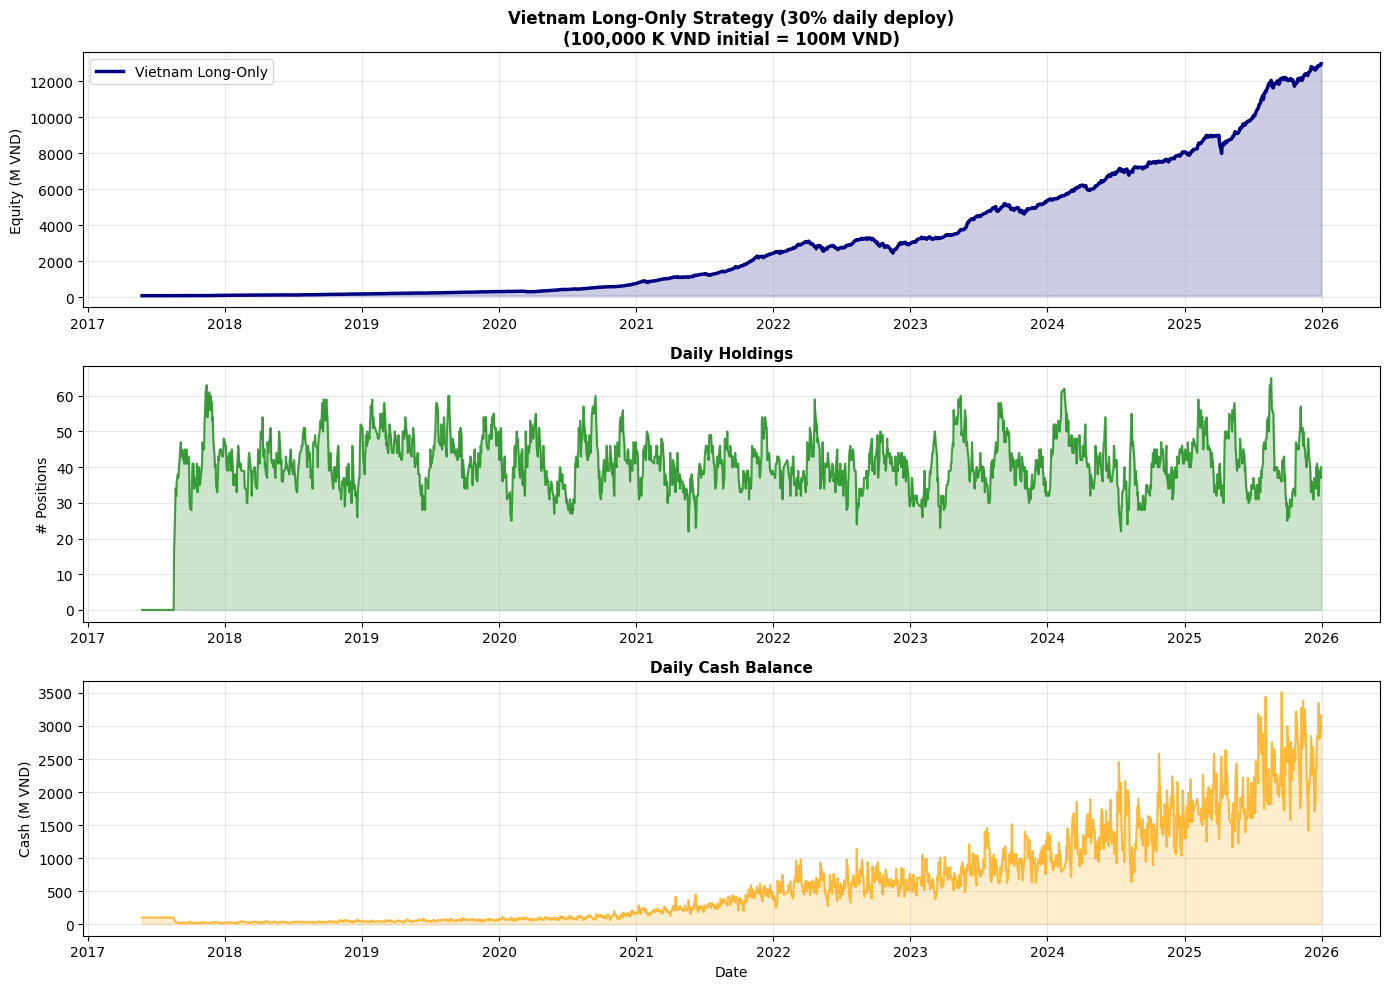

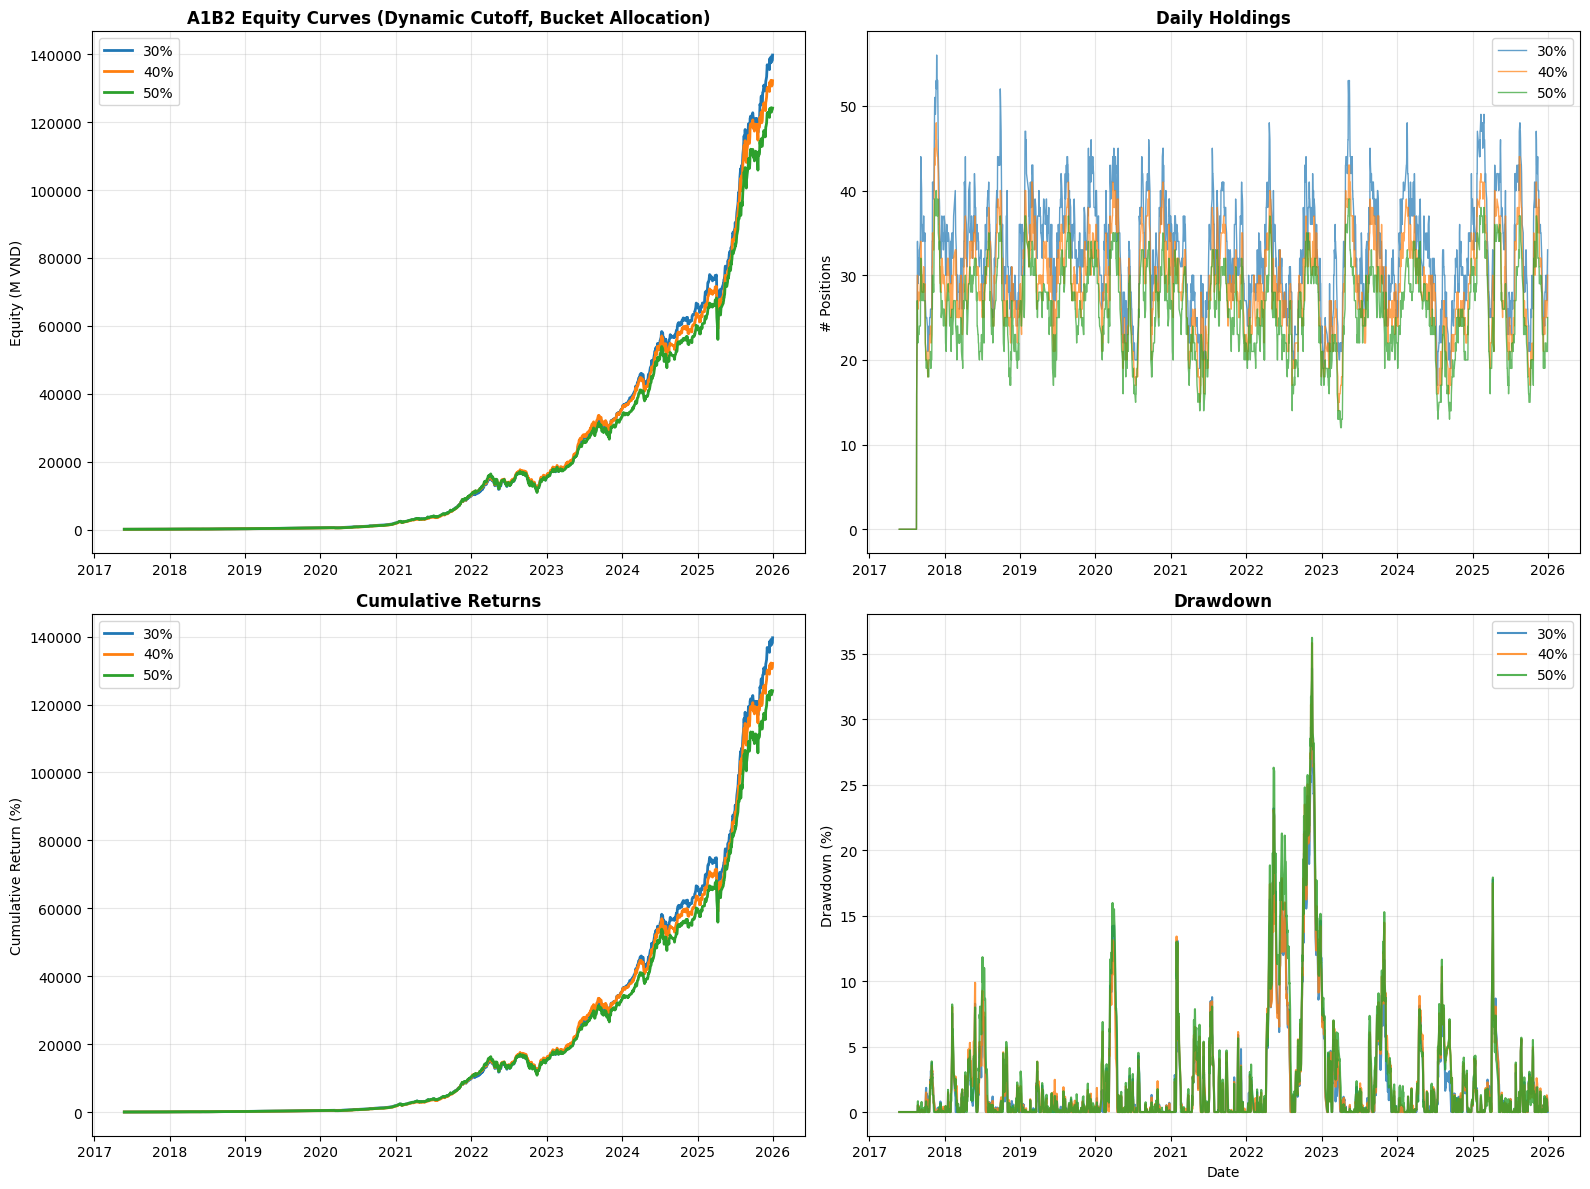

✓ Plots complete


In [23]:
# Plot Vietnam Long-Only
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(equity_longonly.index, equity_longonly.values, linewidth=2.5, color='navy', label='Vietnam Long-Only')
ax.fill_between(equity_longonly.index, equity_longonly.iloc[0], equity_longonly.values, alpha=0.2, color='navy')
ax.set_title('Vietnam Long-Only Strategy (30% daily deploy)\n(100,000 K VND initial = 100M VND)', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity (M VND)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}'))
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(equity_longonly.index, holdings_longonly, linewidth=1.5, color='green', alpha=0.7)
ax.fill_between(equity_longonly.index, 0, holdings_longonly, alpha=0.2, color='green')
ax.set_title('Daily Holdings', fontsize=11, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(cash_longonly.index, cash_longonly.values, linewidth=1.5, color='orange', alpha=0.7)
ax.fill_between(cash_longonly.index, 0, cash_longonly.values, alpha=0.2, color='orange')
ax.set_title('Daily Cash Balance', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cash (M VND)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot A1B2 comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
for frac in [0.30, 0.40, 0.50]:
    eq = results_by_frac[frac]['equity_curve']
    ax.plot(eq.index, eq.values, linewidth=2, label=f'{int(frac*100)}%')
ax.set_title('A1B2 Equity Curves (Dynamic Cutoff, Bucket Allocation)', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity (M VND)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for frac in [0.30, 0.40, 0.50]:
    ax.plot(results_by_frac[frac]['equity_curve'].index, results_by_frac[frac]['holdings_per_day'], 
           linewidth=1, label=f'{int(frac*100)}%', alpha=0.7)
ax.set_title('Daily Holdings', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for frac in [0.30, 0.40, 0.50]:
    eq = results_by_frac[frac]['equity_curve']
    cum_ret = (eq / eq.iloc[0] - 1) * 100
    ax.plot(cum_ret.index, cum_ret.values, linewidth=2, label=f'{int(frac*100)}%')
ax.set_title('Cumulative Returns', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for frac in [0.30, 0.40, 0.50]:
    eq = results_by_frac[frac]['equity_curve']
    cum_max = eq.cummax()
    dd = (cum_max - eq) / cum_max * 100
    ax.plot(dd.index, dd.values, linewidth=1.5, label=f'{int(frac*100)}%', alpha=0.8)
ax.set_title('Drawdown', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Plots complete')

## Step 12: Summary Results

In [24]:
print('\n' + '='*80)
print('FINAL SUMMARY: VIETNAM LONG-ONLY VS A1B2 COMPARISONS')
print('='*80)

print(f'\n1. VIETNAM LONG-ONLY (Dynamic Cutoff A1, 30% Daily Deploy):')
print(f'   Final Equity: {diag_longonly["final_equity"]:,.0f} K VND')
print(f'   Total Return: {diag_longonly["total_return_pct"]:.2f}%')
print(f'   Annualized Return: {diag_longonly["annualized_return"]:.2f}%')
print(f'   Sharpe Ratio: {diag_longonly["sharpe_ratio"]:.4f}')
print(f'   Max Drawdown: {diag_longonly["max_drawdown"]:.2f}%')
print(f'   Avg Holdings: {diag_longonly["avg_holdings"]:.1f}')

print(f'\n2. A1B2 FRAMEWORK (Dynamic Cutoff A1 + Bucket Allocation B2):')
for frac in [0.30, 0.40, 0.50]:
    m = results_by_frac[frac]['metrics']
    print(f'   {int(frac*100)}% fraction: Return={m["total_return_pct"]:.1f}%, Sharpe={m["sharpe_ratio"]:.3f}, DD={m["max_drawdown"]:.1f}%, Holdings={m["avg_holdings"]:.1f}')

print(f'\n3. COMPARISON:')
best_frac = max([0.30, 0.40, 0.50], key=lambda x: results_by_frac[x]['metrics']['sharpe_ratio'])
print(f'   Best Sharpe (A1B2): {int(best_frac*100)}% → {results_by_frac[best_frac]["metrics"]["sharpe_ratio"]:.4f}')
best_return_frac = max([0.30, 0.40, 0.50], key=lambda x: results_by_frac[x]['metrics']['total_return_pct'])
print(f'   Best Return (A1B2): {int(best_return_frac*100)}% → {results_by_frac[best_return_frac]["metrics"]["total_return_pct"]:.1f}%')

print(f'\n4. KEY INSIGHTS:')
print(f'   • Long-Only uses position-based accounting with T+2 settlement constraints')
print(f'   • A1B2 uses equal capital deployment with dynamic cutoff + bucket weighting')
print(f'   • Both strategies deploy 30%+ of capital daily')
print(f'   • Currency: All values in thousands of VND (K VND)')
print(f'   • Initial capital: 100,000 K VND = 100M VND')

print('\n' + '='*80)


FINAL SUMMARY: VIETNAM LONG-ONLY VS A1B2 COMPARISONS

1. VIETNAM LONG-ONLY (Dynamic Cutoff A1, 30% Daily Deploy):
   Final Equity: 12,968,304 K VND
   Total Return: 12868.30%
   Annualized Return: 57.89%
   Sharpe Ratio: 4.3741
   Max Drawdown: 25.55%
   Avg Holdings: 40.3

2. A1B2 FRAMEWORK (Dynamic Cutoff A1 + Bucket Allocation B2):
   30% fraction: Return=139658.2%, Sharpe=4.478, DD=33.9%, Holdings=32.0
   40% fraction: Return=132079.0%, Sharpe=4.236, DD=35.8%, Holdings=28.1
   50% fraction: Return=124036.9%, Sharpe=4.076, DD=36.2%, Holdings=25.0

3. COMPARISON:
   Best Sharpe (A1B2): 30% → 4.4777
   Best Return (A1B2): 30% → 139658.2%

4. KEY INSIGHTS:
   • Long-Only uses position-based accounting with T+2 settlement constraints
   • A1B2 uses equal capital deployment with dynamic cutoff + bucket weighting
   • Both strategies deploy 30%+ of capital daily
   • Currency: All values in thousands of VND (K VND)
   • Initial capital: 100,000 K VND = 100M VND

